In [1]:
# Reviewer: Alexander Volkovich.

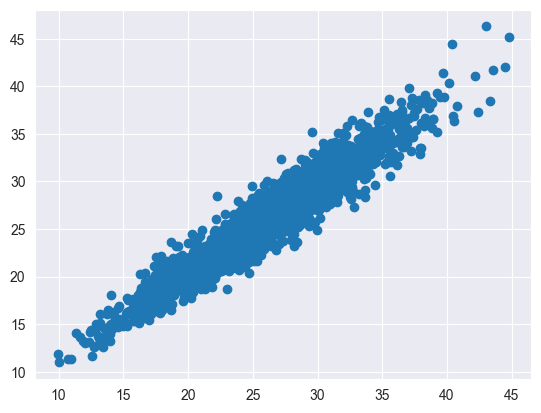

In [2]:
from sklearn.linear_model import Lasso, ElasticNet, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
data_n = 10000
features_n = 10
data = np.random.rand(data_n, features_n)
beta0 = np.array([0.1])
betas = np.random.randint(low=1, high=10, size=features_n)

y = beta0 + betas @ data.T + np.random.randn(data_n)
data = data * (1 + np.random.randn(data_n, 1) * 0.05)
x_train, x_test, y_train, y_test = train_test_split(data, y.T, test_size=0.2)

linear = LinearRegression()
linear.fit(x_train, y_train)
linear.score(x_test, y_test)
plt.scatter(y_test, linear.predict(x_test))
alpha = 0.01
scores = []
l1_ratio = 0.01
for i in range(9):
    alpha = 0.01
    for j in range(9):
        elastic_net = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
        elastic_net.fit(x_train, y_train)
        scores.append(elastic_net.score(x_test, y_test))
        alpha += 0.01
    l1_ratio += 0.01

In [3]:
l1_ratio = scores.index(max(scores)) / 9900
alpha = 0.1

elastic_net = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
elastic_net.fit(x_train, y_train)
elastic_net.score(x_test, y_test)

0.6541224212940911

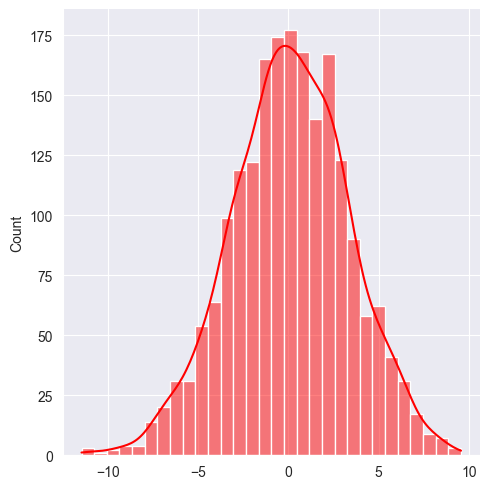

In [4]:
import seaborn as sns

residuals = elastic_net.predict(x_test) - y_test
sns.displot(residuals, kde=True, bins=30, color="red")
plt.show()